In [ ]:
!pip install -q ultralytics
!pip install -q torchvision torch
!pip install -q pycocotools
!pip install -q matplotlib opencv-python tqdm

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.0 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
from pathlib import Path
BASE_DIR = Path("/content/drive/MyDrive/Warning_Triangle_Dataset")
TARGET_DIR = Path("/content/drive/MyDrive/FIXED_Warning_Triangle_Dataset")

TRAIN = BASE_DIR / "train" / "images"
print(len(list(TRAIN.iterdir())))

926


In [ ]:
TARGET_DIR.mkdir(parents=True, exist_ok=True)

for split in ['train', 'val', 'test']:
    (TARGET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (TARGET_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

print(f"Target directory structure created at: {TARGET_DIR}")

# Verify the creation (optional, for demonstration)
for split in ['train', 'val', 'test']:
    print(f"Checking: {TARGET_DIR / split / 'images'} exists = {(TARGET_DIR / split / 'images').exists()}")
    print(f"Checking: {TARGET_DIR / split / 'labels'} exists = {(TARGET_DIR / split / 'labels').exists()}")

Target directory structure created at: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset
Checking: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/train/images exists = True
Checking: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/train/labels exists = True
Checking: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/val/images exists = True
Checking: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/val/labels exists = True
Checking: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/images exists = True
Checking: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/labels exists = True


In [ ]:
import random

all_files = []

# Assuming labels are in BASE_DIR / "train" / "labels"
LABELS_DIR = BASE_DIR / "train" / "labels"

for image_path in TRAIN.iterdir():
    if image_path.is_file() and image_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        label_filename = f"{image_path.stem}.txt"
        label_path = LABELS_DIR / label_filename

        if label_path.is_file():
            all_files.append((str(image_path), str(label_path)))

random.shuffle(all_files)

print(f"Collected and shuffled {len(all_files)} image-label pairs.")
# Display the first 5 pairs to verify
print("First 5 shuffled pairs:")
for i, (img, lbl) in enumerate(all_files[:5]):
    print(f"  Image: {Path(img).name}, Label: {Path(lbl).name}")

Collected and shuffled 926 image-label pairs.
First 5 shuffled pairs:
  Image: 2022-11-17-15-46-23_L2_Xavier_9Cam_Warning_Triangle_Urban_csi_cam_front_center_middle_image_raw-1668728792101_png.rf.fd38a5eb402ff53b17747509f377c70b.jpg, Label: 2022-11-17-15-46-23_L2_Xavier_9Cam_Warning_Triangle_Urban_csi_cam_front_center_middle_image_raw-1668728792101_png.rf.fd38a5eb402ff53b17747509f377c70b.txt
  Image: 2022-11-17-18-12-03_L2_Xavier_9Cam_Warning_Triangle_Urban_Night_csi_cam_front_center_crop_image_raw-1668737532363_png.rf.56ac3f7e5be4ad2e7d4e0d4ed179edd1.jpg, Label: 2022-11-17-18-12-03_L2_Xavier_9Cam_Warning_Triangle_Urban_Night_csi_cam_front_center_crop_image_raw-1668737532363_png.rf.56ac3f7e5be4ad2e7d4e0d4ed179edd1.txt
  Image: 2022-11-17-18-05-54_L2_Xavier_9Cam_Warning_Triangle_Urban_Night_annot_agx_front_center_narrow_image_raw-1668737156395_png.rf.bca82faedc211f7ce64fde1f21761f3e.jpg, Label: 2022-11-17-18-05-54_L2_Xavier_9Cam_Warning_Triangle_Urban_Night_annot_agx_front_center_narrow

In [ ]:
total_files = len(all_files)

train_split_idx = int(total_files * 0.8)
val_split_idx = int(total_files * 0.1)

train_files = all_files[:train_split_idx]
val_files = all_files[train_split_idx : train_split_idx + val_split_idx]
test_files = all_files[train_split_idx + val_split_idx:]

print(f"Number of total files: {total_files}")
print(f"Number of training files: {len(train_files)}")
print(f"Number of validation files: {len(val_files)}")
print(f"Number of test files: {len(test_files)}")

Number of total files: 926
Number of training files: 740
Number of validation files: 92
Number of test files: 94


In [ ]:
import shutil
from tqdm import tqdm

def copy_files_to_split(file_list, split_name):
    image_target_dir = TARGET_DIR / split_name / 'images'
    label_target_dir = TARGET_DIR / split_name / 'labels'

    print(f"Copying {len(file_list)} files to {split_name}...")
    for img_src, lbl_src in tqdm(file_list, desc=f"Copying to {split_name}"):
        img_name = Path(img_src).name
        lbl_name = Path(lbl_src).name

        shutil.copy(img_src, image_target_dir / img_name)
        shutil.copy(lbl_src, label_target_dir / lbl_name)
    print(f"Finished copying files for {split_name} split.")

# Copy files for each split
copy_files_to_split(train_files, 'train')
copy_files_to_split(val_files, 'val')
copy_files_to_split(test_files, 'test')

print("All files have been copied to their respective target directories.")

Copying 740 files to train...


Copying to train: 100%|██████████| 740/740 [06:05<00:00,  2.03it/s]


Finished copying files for train split.
Copying 92 files to val...


Copying to val: 100%|██████████| 92/92 [00:42<00:00,  2.14it/s]


Finished copying files for val split.
Copying 94 files to test...


Copying to test: 100%|██████████| 94/94 [00:49<00:00,  1.92it/s]

Finished copying files for test split.
All files have been copied to their respective target directories.


In [ ]:
for split in ['train', 'val', 'test']:
    image_dir = TARGET_DIR / split / 'images'
    label_dir = TARGET_DIR / split / 'labels'

    num_images = len(list(image_dir.iterdir()))
    num_labels = len(list(label_dir.iterdir()))

    print(f"\n{split.capitalize()} Split:")
    print(f"  Images: {num_images} files")
    print(f"  Labels: {num_labels} files")


Train Split:
  Images: 740 files
  Labels: 740 files

Val Split:
  Images: 92 files
  Labels: 92 files

Test Split:
  Images: 94 files
  Labels: 94 files


In [ ]:
for split in ['train', 'val', 'test']:
    labels_dir = TARGET_DIR / split / 'labels'

    print(f"Standardizing labels in {labels_dir}...")
    for label_file in tqdm(list(labels_dir.iterdir()), desc=f"Processing {split} labels"):
        if label_file.suffix == '.txt':
            modified_lines = []
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split(' ')
                    if len(parts) > 0:
                        parts[0] = '0' # Standardize class ID to '0'
                    modified_lines.append(' '.join(parts))

            with open(label_file, 'w') as f:
                for line in modified_lines:
                    f.write(line + '\n')

print("Label standardization complete for all splits.")

Standardizing labels in /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/train/labels...


Processing train labels: 100%|██████████| 740/740 [00:10<00:00, 73.57it/s]


Standardizing labels in /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/val/labels...


Processing val labels: 100%|██████████| 92/92 [00:00<00:00, 106.66it/s]


Standardizing labels in /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/labels...


Processing test labels: 100%|██████████| 94/94 [00:00<00:00, 96.19it/s]

Label standardization complete for all splits.


In [ ]:
from pathlib import Path
import math

def poly_to_bbox(coords):
    xs = coords[0::2]
    ys = coords[1::2]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    xc = (x_min + x_max) / 2
    yc = (y_min + y_max) / 2
    w  = (x_max - x_min)
    h  = (y_max - y_min)
    return xc, yc, w, h

def merge_bboxes(bboxes):
    # bboxes: list of (xc,yc,w,h) normalized
    # convert to (x1,y1,x2,y2) merge, back to xc,yc,w,h
    x1s, y1s, x2s, y2s = [], [], [], []
    for xc,yc,w,h in bboxes:
        x1s.append(xc - w/2); y1s.append(yc - h/2)
        x2s.append(xc + w/2); y2s.append(yc + h/2)
    x1, y1, x2, y2 = min(x1s), min(y1s), max(x2s), max(y2s)
    xc = (x1+x2)/2; yc=(y1+y2)/2; w=(x2-x1); h=(y2-y1)
    return xc,yc,w,h

for split in ["train","val","test"]:
    labels_dir = TARGET_DIR / split / "labels"
    for f in labels_dir.glob("*.txt"):
        lines = f.read_text().strip().splitlines()
        bboxes = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            coords = list(map(float, parts[1:]))
            bboxes.append(poly_to_bbox(coords))

        if not bboxes:
            f.write_text("")  # no label
            continue

        # gabung polygon + polygon-hole jadi 1 bbox
        xc,yc,w,h = merge_bboxes(bboxes)
        f.write_text(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

print("Done: polygon -> single bbox per image.")


Done: polygon -> single bbox per image.


In [ ]:
data_yaml_content_corrected = f"""path: {TARGET_DIR}
train: train/images
val: val/images
test: test/images

nc: 1
names:
  0: warning_triangle
"""

data_yaml_path = TARGET_DIR / "data.yaml"

with open(data_yaml_path, 'w') as f:
    f.write(data_yaml_content_corrected)

print(f"Updated data.yaml at: {data_yaml_path}")
print("Content of updated data.yaml:")
print(data_yaml_content_corrected)

Updated data.yaml at: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/data.yaml
Content of updated data.yaml:
path: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset
train: train/images
val: val/images
test: test/images

nc: 1
names:
  0: warning_triangle



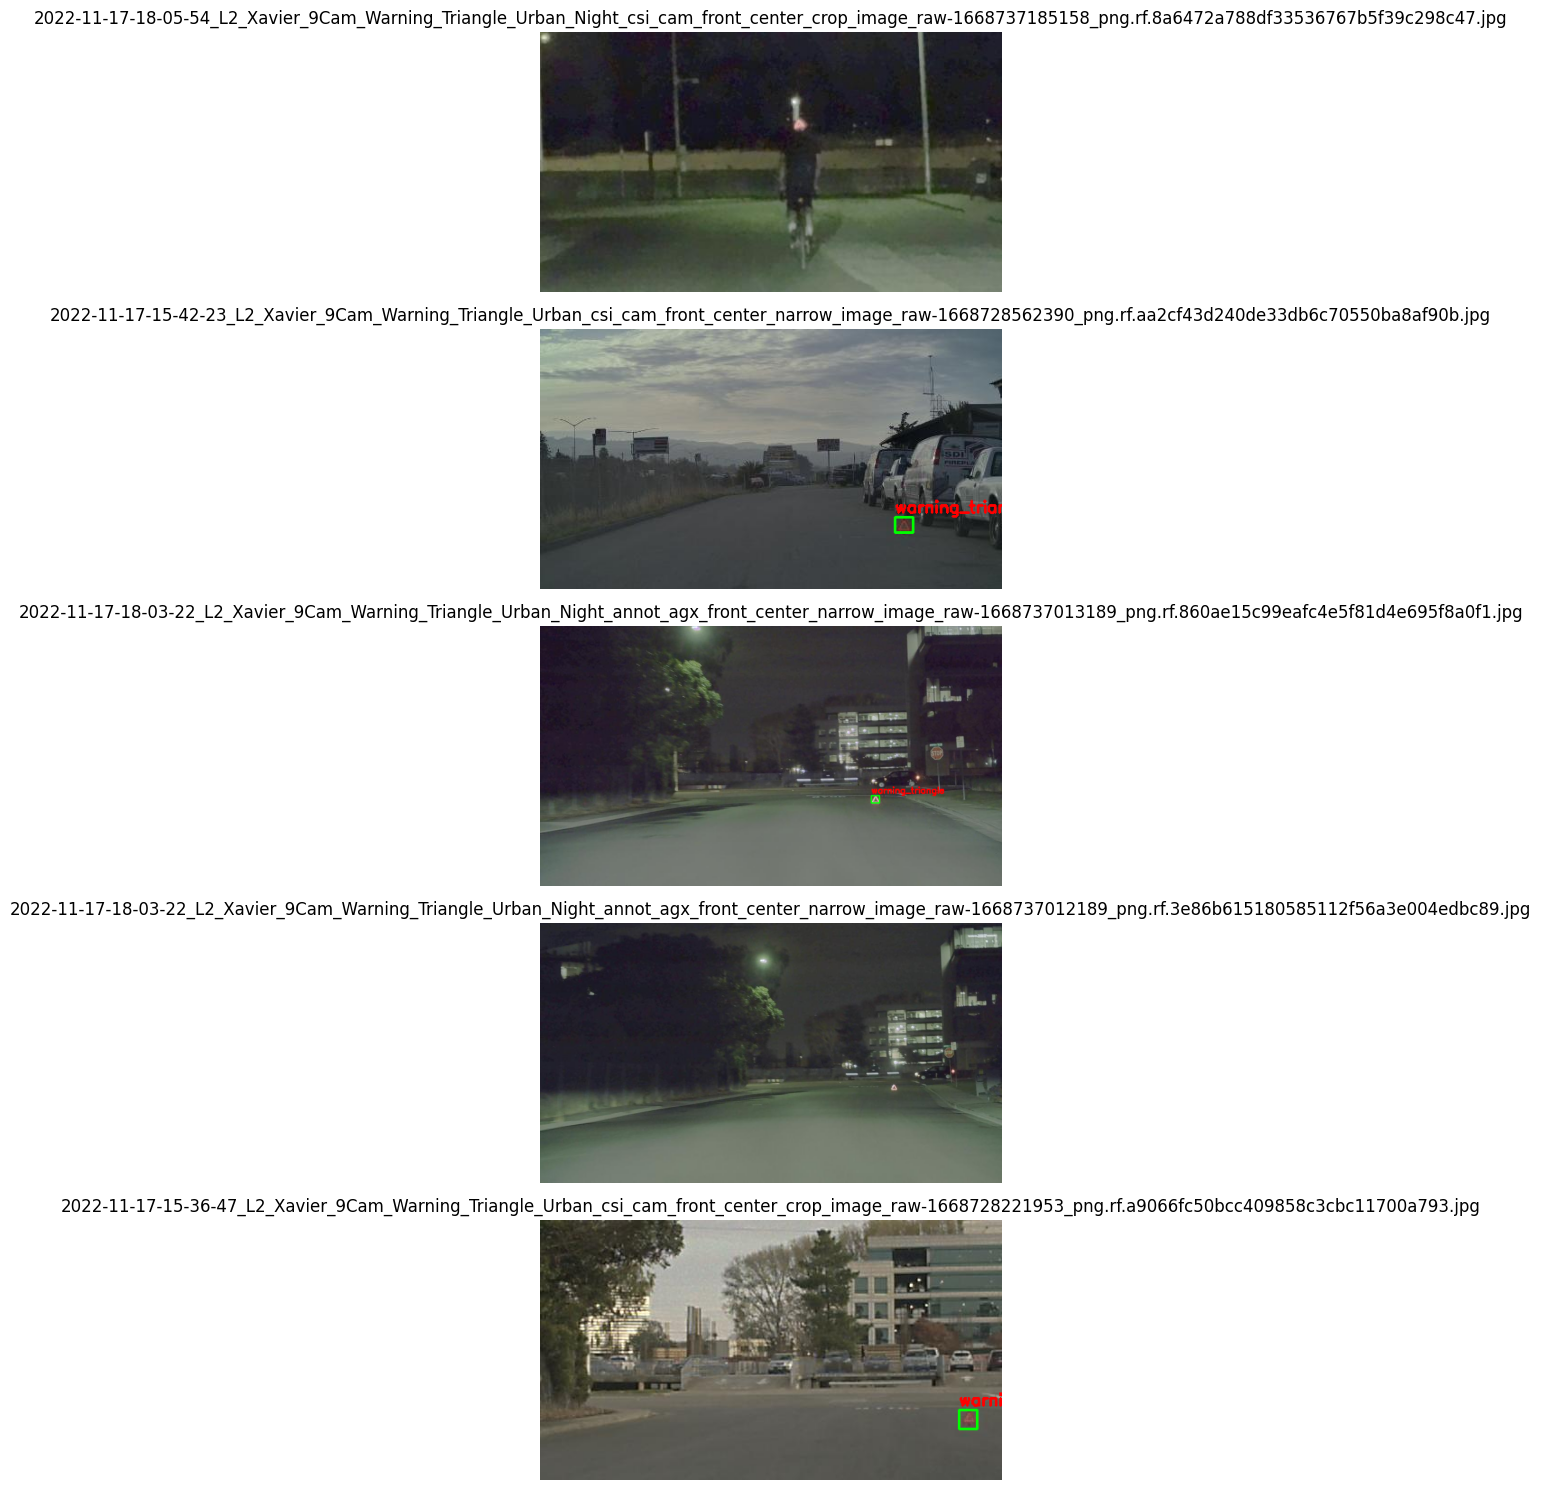

In [ ]:
import random
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Define the class names, as per data.yaml
CLASSES = {0: 'warning_triangle'}

# Define image and label directories for the training split
IMG_TRAIN = TARGET_DIR / "train" / "images"
LBL_TRAIN = TARGET_DIR / "train" / "labels"

def visualize_samples(img_dir, lbl_dir, n=5):
    """Visualizes N random images from img_dir with their bounding box labels from lbl_dir."""
    # Ensure there are enough images to sample
    all_images = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
      all_images += list(img_dir.glob(ext))

    if not all_images:
        print(f"No .jpg images found in {img_dir}")
        return

    if len(all_images) < n:
        print(f"Warning: Only {len(all_images)} images available, visualizing all of them.")
        imgs_to_visualize = all_images
    else:
        imgs_to_visualize = random.sample(all_images, n)

    plt.figure(figsize=(15, 3 * len(imgs_to_visualize)))
    for i, img_path in enumerate(imgs_to_visualize):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for matplotlib
        h, w = img.shape[:2]

        # Construct label path by replacing image suffix with .txt
        label_filename = img_path.stem + ".txt"
        lbl_path = lbl_dir / label_filename

        if lbl_path.is_file():
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id, xc, yc, bw, bh = map(float, parts[:5])
                        # Convert YOLO format (center_x, center_y, width, height) to (x1, y1, x2, y2)
                        x1 = int((xc - bw / 2) * w)
                        y1 = int((yc - bh / 2) * h)
                        x2 = int((xc + bw / 2) * w)
                        y2 = int((yc + bh / 2) * h)

                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green rectangle

                        # Get class name safely
                        class_name = CLASSES.get(int(cls_id), f"Class {int(cls_id)}")
                        cv2.putText(img, class_name, (x1, y1 - 5),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2) # Red text

        plt.subplot(len(imgs_to_visualize), 1, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)

    plt.tight_layout()
    plt.show()

# Call the visualization function for the training split
visualize_samples(IMG_TRAIN, LBL_TRAIN, n=5)

In [ ]:
from pathlib import Path

def check_split(split):
    lbl_dir = TARGET_DIR / split / "labels"
    empty = 0
    bad = 0
    total = 0

    for f in lbl_dir.glob("*.txt"):
        total += 1
        txt = f.read_text().strip()
        if not txt:
            empty += 1
            continue

        parts = txt.split()
        if len(parts) != 5:
            bad += 1
            continue

        cls, xc, yc, w, h = map(float, parts)
        if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
            bad += 1

    print(f"{split}: total={total}, empty={empty}, bad={bad}")

for s in ["train", "val", "test"]:
    check_split(s)


train: total=740, empty=182, bad=0
val: total=92, empty=24, bad=0
test: total=94, empty=16, bad=0


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # bisa upgrade ke yolov8s.pt kalau perlu lebih akurat

results = model.train(
    data=str(TARGET_DIR / "data.yaml"),
    imgsz=960,
    epochs=150,
    batch=16,
    device=0,
    workers=2,
    patience=30,
    cache=True
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=

In [ ]:
best_model_path = "runs/detect/train/weights/best.pt"
best_model = YOLO(best_model_path)

metrics = best_model.val(data=str(TARGET_DIR / "data.yaml"), imgsz=960)
print(metrics)

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 12.5±6.9 MB/s, size: 40.0 KB)
val: Scanning /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/val/labels.cache... 92 images, 24 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 20.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.4it/s 4.4s
                   all         92         68      0.825      0.926      0.912      0.604
Speed: 13.0ms preprocess, 12.1ms inference, 0.0ms loss, 4.7ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c75848398e0>
curves: ['Precision-Recall(B)', '

In [ ]:
from pathlib import Path
import shutil

RUN_DIR = Path("/content/runs/detect/train/weights")
best_pt = RUN_DIR / "best.pt"
last_pt = RUN_DIR / "last.pt"

SAVE_DIR = Path("/content/drive/MyDrive/WarningTriangleModel")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy2(best_pt, SAVE_DIR / "best.pt")
shutil.copy2(last_pt, SAVE_DIR / "last.pt")

print("Saved to:", SAVE_DIR)
print("Files:", list(SAVE_DIR.iterdir()))


Saved to: /content/drive/MyDrive/WarningTriangleModel
Files: [PosixPath('/content/drive/MyDrive/WarningTriangleModel/best.pt'), PosixPath('/content/drive/MyDrive/WarningTriangleModel/last.pt')]


In [ ]:
from ultralytics import YOLO
from pathlib import Path

MODEL_PATH = "/content/drive/MyDrive/WarningTriangleModel/best.pt"
SOURCE_DIR = str(TARGET_DIR / "test" / "images")

model = YOLO(MODEL_PATH)

results = model.predict(
    source=SOURCE_DIR,
    imgsz=960,
    conf=0.20,
    iou=0.5,
    save=True,
    project="/content/drive/MyDrive/WarningTrianglePredictions",
    name="test_pred"
)

print("Done. Output saved to Drive.")



image 1/94 /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/images/2022-11-17-15-34-23_L2_Xavier_9Cam_Warning_Triangle_Urban_annot_agx_front_center_crop_image_raw-1668728073416_png.rf.2cffdfaaf9399e63e21479834416c047.jpg: 512x960 1 warning_triangle, 78.6ms
image 2/94 /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/images/2022-11-17-15-34-23_L2_Xavier_9Cam_Warning_Triangle_Urban_annot_agx_front_center_crop_image_raw-1668728075192_png.rf.64a0ecf2d5cad5479a146827f285d7b0.jpg: 512x960 1 warning_triangle, 7.9ms
image 3/94 /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/images/2022-11-17-15-34-23_L2_Xavier_9Cam_Warning_Triangle_Urban_annot_agx_front_center_crop_image_raw-1668728076376_png.rf.595213b3b7da902cfa1678053c09cdf6.jpg: 512x960 1 warning_triangle, 7.9ms
image 4/94 /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/images/2022-11-17-15-34-23_L2_Xavier_9Cam_Warning_Triangle_Urban_annot_agx_front_center_crop_image_raw-1668728079215_png.rf.26b6c1

In [ ]:
import json

metrics = model.val(
    data=str(TARGET_DIR / "data.yaml"),
    split="test",
    imgsz=960,
    conf=0.20,
    iou=0.5
)

metrics_dict = {
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
}

save_path = "/content/drive/MyDrive/WarningTrianglePredictions/test_metrics.json"
with open(save_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Metrics saved to:", save_path)


Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 27.8±11.3 MB/s, size: 51.4 KB)
val: Scanning /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/labels... 94 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 94/94 5.8it/s 16.2s
val: New cache created: /content/drive/MyDrive/FIXED_Warning_Triangle_Dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.8s
                   all         94         78      0.866      0.885      0.894      0.535
Speed: 4.2ms preprocess, 7.2ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
Metrics saved to: /content/drive/MyDrive/WarningTrianglePredictions/test_metrics.json
